In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import csv
random.seed(1)

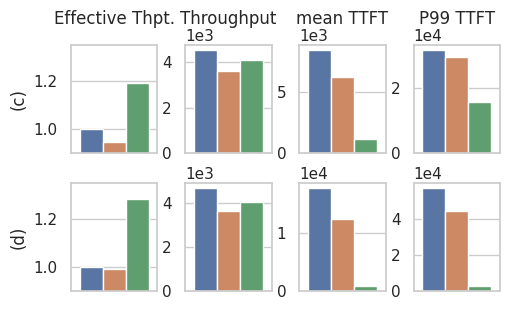

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
file_path = 'Buffer-Aware-H200图.csv'  # Change if necessary
df = pd.read_csv(file_path)

# Clean the data
df_clean = df.dropna(axis=1, how='all')
df_clean = df_clean[df_clean['workload'].notna()]

# plot_workloads = ['burst 60(512+2048)', 'burst 80(1024+2048)']
# plot_workloads = ['P(2) 60(512+2048)', 'P(4) 100(512+2048)']
# plot_workloads = ['burst 400(512+2048)', 'burst 200(1024+4096)']
plot_workloads = ['(c)', '(d)']

# Setup
df_clean = df_clean[df_clean['workload'].isin(plot_workloads)]
df_clean = df_clean[df_clean['speed'] == 25]
workloads = df_clean['workload'].unique()
measurements = ['Effective Thpt.', 'Throughput', 'mean TTFT', 'P99 TTFT']

# Create figure and axes
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(5, 3), sharey=False)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Plotting
for i, workload in enumerate(workloads):
    df_workload = df_clean[df_clean['workload'] == workload].copy()
    
    for j, metric in enumerate(measurements):
        ax = axes[i, j]
        
        # Normalize effective throughput
        if metric == 'Effective Thpt.':
            norm_values = []
            for speed in df_workload['speed'].unique():
                group = df_workload[df_workload['speed'] == speed]
                ours_val = group[group['method'] == 'sglang'][metric].values
                if len(ours_val) > 0 and ours_val[0] != 0:
                    norm = group.copy()
                    norm[metric] = norm[metric] / ours_val[0]
                    norm_values.append(norm)
            df_plot = pd.concat(norm_values) if norm_values else df_workload
        else:
            df_plot = df_workload

        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        sns.barplot(
            data=df_plot,
            y=metric,
            hue='method',
            ax=ax,
        )

        # Axis labels
        if i == 3:
            ax.set_xlabel('Speed')
        else:
            ax.set_xlabel('')
        if j == 0:
            ax.set_ylabel(workload)
            ax.set_ylim(0.9, 1.35)
        else:
            ax.set_ylabel('')

        ax.legend_.remove()

        # Top row: set metric as column label
        if i == 0:
            ax.set_title(metric, fontsize=12, pad=15)


# Add shared legend at the top
# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=len(labels), title='Method', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 1], pad=0.3)  # Reserve space for legend
plt.savefig('3-H200-poisson.pdf', dpi=300, bbox_inches='tight')
plt.show()

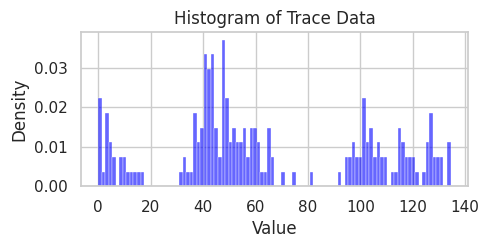

In [ ]:
with open("trace.log", "r") as f:
    trace = list(map(float, f))
    trace = trace[:int(len(trace) / 3)]
    trace = random.sample(trace, 200)
    trace.sort()
trace = [item - trace[0] for item in trace]
trace = [item * 7e-4 for item in trace]

# plot a histogram to show the distribution of the data
plt.figure(figsize=(5, 2))
sns.histplot(trace, bins=100, stat='density', color='blue', alpha=0.6)
plt.title('Histogram of Trace Data')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(True)


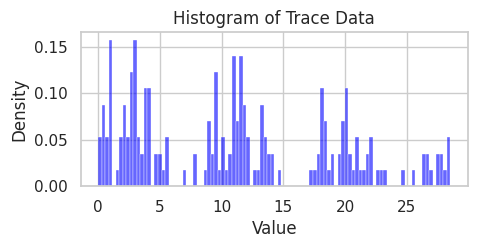

In [18]:
with open("BurstGPT_1.csv", "r") as f:
    reader = csv.reader(f)
    _ = next(reader)  # Skip header
    trace = []
    for _, row in zip(range(10000), reader): # prune the trace here
        row[0] = float(row[0])
        trace.append(row)
    trace = random.sample(trace, 200)
    trace.sort()
    trace = [float(x[0]) for x in trace]
    trace = [item - trace[0] for item in trace]
    trace = [item * 1e-4 for item in trace]

# plot a histogram to show the distribution of the data
plt.figure(figsize=(5, 2))
sns.histplot(trace, bins=100, stat='density', color='blue', alpha=0.6)
plt.title('Histogram of Trace Data')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(True)